In [1]:
import numpy as np

HBAR = 1.0

class DiabaticTwoState1D:
    """
    Base class for a 1D two-state system defined in a diabatic basis.

    You must implement:
        H(q)     -> 2x2 diabatic Hamiltonian matrix
        dH_dq(q) -> 2x2 derivative of Hamiltonian wrt q

    This class then provides:
        - adiabatic energies and NACs
        - forces on adiabatic surfaces
        - interface required by the MASH integrator
    """

    def __init__(self, mass=1.0):
        self.mass = float(mass)

    # ---- user must override these two ----
    def H(self, q: float) -> np.ndarray:
        raise NotImplementedError

    def dH_dq(self, q: float) -> np.ndarray:
        raise NotImplementedError

    # ---- internal helper: adiabatic info at q ----
    def adiabatic_info(self, q: float):
        H = self.H(q)
        dH = self.dH_dq(q)

        eigvals, eigvecs = np.linalg.eigh(H)
        idx = np.argsort(eigvals)
        V0, V1 = eigvals[idx]
        C = eigvecs[:, idx]

        dV0_dq = np.real(np.vdot(C[:, 0], dH @ C[:, 0]))
        dV1_dq = np.real(np.vdot(C[:, 1], dH @ C[:, 1]))

        num_10 = np.vdot(C[:, 1], dH @ C[:, 0])   # <1| dH/dq |0>
        denom_10 = V0 - V1

        # regularise NAC near degeneracy
        eps = 1e-8
        if abs(denom_10) < eps:
            d10 = 0.0   # or smoothly clamp, but zero is fine for a start
        else:
            d10 = np.real(num_10 / denom_10)

        return V0, V1, dV0_dq, dV1_dq, d10, C

    # ---- API used by the integrator ----

    def V0(self, q: float) -> float:
        V0, V1, _, _, _, _ = self.adiabatic_info(q)
        return V0

    def V1(self, q: float) -> float:
        V0, V1, _, _, _, _ = self.adiabatic_info(q)
        return V1

    def V(self, a: int, q: float) -> float:
        """Adiabatic energy on state a (0 or 1)."""
        if a == 0:
            return self.V0(q)
        elif a == 1:
            return self.V1(q)
        else:
            raise ValueError("State index a must be 0 or 1.")

    def F(self, a: int, q: float) -> float:
        """
        Force on adiabatic state a (0 or 1):
            F_a(q) = -dV_a/dq
        """
        V0, V1, dV0_dq, dV1_dq, _, _ = self.adiabatic_info(q)
        if a == 0:
            return -dV0_dq
        elif a == 1:
            return -dV1_dq
        else:
            raise ValueError("State index a must be 0 or 1.")

    def d_an(self, q: float, a: int) -> float:
        """
        Nonadiabatic coupling d_{a n}(q) with n = 1 - a.

        Convention from adiabatic_info:
            d10 = <1|∂/∂q|0>

        For a 2-state, real-valued gauge, we have:
            d01 = -d10

        We return d_{a n} consistently:

            if a = 0, n = 1: d_{0 1} = -d10
            if a = 1, n = 0: d_{1 0} = d10
        """
        _, _, _, _, d10, _ = self.adiabatic_info(q)
        if a == 0:
            # a=0, n=1: d_01 = -d_10
            return -d10
        elif a == 1:
            # a=1, n=0: d_10
            return d10
        else:
            raise ValueError("State index a must be 0 or 1.")
    
    def eigvecs(self, q):
        _, _, _, _, _, eigvecs = self.adiabatic_info(q)
        return eigvecs

class LandauZener(DiabaticTwoState1D):
    """
    1D avoided crossing from Landau-Zener model
    """
    def __init__(self, s, vc, mass=1):
        super().__init__(mass)
        self.s = s
        self.vc = vc
    
    def H(self, q):
        V11 = 0.0
        V12 = self.vc
        V22 = self.s * q
        return np.array([[V11, V12], [V12, V22]], dtype=float)
    
    def dH_dq(self, q):
        dV11 = 0.0
        dV12 = 0.0
        dV22 = self.s
        return np.array([[dV11, dV12], [dV12, dV22]], dtype=float)

def Landau_traj(v, t, t0):
    q = v * (t-t0)
    return q

def lowdin_orthogonalization(S):
    """
    Compute T = S (S^† S)^(-1/2)
    """

    # A = S^† S
    A = S.conj().T @ S

    # Diagonalize A (Hermitian → eigh)
    eigvals, eigvecs = np.linalg.eigh(A)

    # Inverse square root of eigenvalues
    # (add tiny regularization for safety)
    eps = 1e-14
    inv_sqrt = np.diag(1.0 / np.sqrt(eigvals + eps))

    # A^{-1/2}
    A_inv_sqrt = eigvecs @ inv_sqrt @ eigvecs.conj().T

    # T
    T = S @ A_inv_sqrt

    return T

def unitary_propagator(A, dt, hbar=1.0):
    """
    Compute U = exp(-i A dt / hbar)
    for Hermitian 2x2 matrix A.
    """

    # Diagonalize A
    eigvals, eigvecs = np.linalg.eigh(A)

    # Exponentiate eigenvalues
    phases = np.exp(-1j * eigvals * dt / hbar)

    # Reconstruct U
    U = eigvecs @ np.diag(phases) @ eigvecs.conj().T

    return U

def align_phases_real(C_prev, C_curr):
    """
    Enforce phase continuity between eigenvector matrices.
    Columns are eigenvectors.
    """
    C_aligned = C_curr.copy()

    for i in range(C_prev.shape[1]):
        overlap = np.vdot(C_prev[:, i], C_curr[:, i])
        if np.real(overlap) < 0:
            C_aligned[:, i] *= -1.0

    return C_aligned

def align_phases(C_prev, C_curr, eps=1e-14):
    C = C_curr.copy()
    for i in range(C_prev.shape[1]):
        ov = np.vdot(C_prev[:, i], C[:, i])  # <prev|curr>
        mag = np.abs(ov)
        if mag > eps:
            C[:, i] *= (ov.conjugate() / mag)  # multiply by e^{-i arg(ov)}
    return C

# class DoubleHarmonic(DiabaticTwoState1D):
#     '''
#     1D avoided crossing from two horizontally displaced simple harmonic oscillators.
#     '''

#     def __init__(self, k, x0, vc, mass=1):
#         super().__init__(mass)
#         self.k = k
#         self.x0 = x0
#         self.vc = vc
    
#     def H(self, q):
#         V11 = 1/2 * self.k * (q-self.x0)**2
#         V12 = self.vc
#         V22 = 1/2 * self.k * (q+self.x0)**2
#         return np.array([[V11, V12], [V12, V22]], dtype=complex)
    
#     def dH_dq(self, q):
#         dV11 = self.k * (q-self.x0)
#         dV22 = self.k * (q+self.x0)
#         dV12 = 0.0
#         return np.array([[dV11, dV12], [dV12, dV22]])

# class SimpleAvoidedCrossing(DiabaticTwoState1D):
#     """
#     Example: Tully-like 1D avoided crossing in a diabatic representation.

#     Diabatic Hamiltonian:
#         H_11(q) =  A (1 - tanh(B q))
#         H_22(q) = -A (1 - tanh(B q))
#         H_12(q) =  C exp(-D q^2)

#     You can change A, B, C, D to define different models.
#     """

#     def __init__(self, A=0.01, B=1.6, C=0.005, D=1.0, mass=1.0):
#         super().__init__(mass=mass)
#         self.A = A
#         self.B = B
#         self.C = C
#         self.D = D

#     def H(self, q: float) -> np.ndarray:
#         V11 = self.A * (1.0 - np.tanh(self.B * q))
#         V22 = -self.A * (1.0 - np.tanh(self.B * q))
#         V12 = self.C * np.exp(-self.D * q**2)
#         return np.array([[V11, V12],
#                          [V12, V22]], dtype=float)

#     def dH_dq(self, q):
#         # Use sech^2 = 1 - tanh^2 to avoid cosh overflow
#         Bq = self.B * q
#         tanh_Bq = np.tanh(Bq)
#         sech2 = 1.0 - tanh_Bq**2  # = 1 / cosh^2(Bq) but numerically stable

#         dV11 = -self.A * self.B * sech2
#         dV22 = -dV11

#         V12 = self.C * np.exp(-self.D * q**2)
#         dV12 = -2.0 * self.D * q * V12

#         return np.array([[dV11, dV12],
#                         [dV12, dV22]], dtype=float)

(-0.1, 0.1)

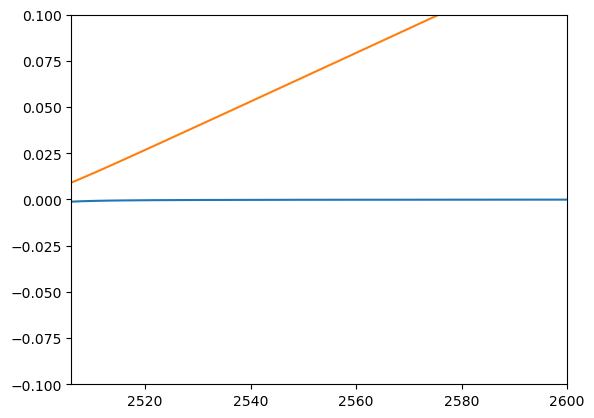

In [8]:
dt = 0.1
v = 0.002
c = 0.0033
s = 0.66
n_int = 5.0/(v * dt)
k = 0
t0 = dt * (n_int + k/10)
t = np.arange(0, 8269, dt)
tau = 4 * np.abs(c)/np.abs(s * v)
P12 = 1 - np.exp(-2 * np.pi * c**2 / abs(s * v))
traj = np.array([Landau_traj(v=0.002, t=tn, t0=t0) for tn in t])

LZ_H = LandauZener(s=s, vc=c)

e_low = np.array([LZ_H.V0(traj[i]) for i in range(len(traj))])
e_high = np.array([LZ_H.V1(traj[i]) for i in range(len(traj))])
nac = np.array([LZ_H.d_an(traj[i], a=1) for i in range(len(traj))])

from matplotlib import pyplot as plt

plt.figure()
plt.plot(t, e_low)
plt.plot(t, e_high)
# plt.plot(t, np.abs(nac))
plt.xlim([2506, 2600])
plt.ylim([-0.1, 0.1])

In [ ]:
from scipy.linalg import expm


dt = 40
v = 0.002
c = 0.0033
s = 0.66
n_int = 5.0/(v * dt)
k = 0
t0 = dt * (n_int + k/10)
t = np.arange(0, 8269, dt)
tau = 4 * np.abs(c)/np.abs(s * v)
print('tau as a basic time unit', tau)
P12 = 1 - np.exp(-2 * np.pi * c**2 / abs(s * v))
print('P12', P12)
traj = np.array([Landau_traj(v=0.002, t=tn, t0=t0) for tn in t])
coeff = np.array([1.0, 0.0], dtype=complex)
coeff_store = [coeff]

q_start = traj[0]
C_curr = LZ_H.eigvecs(q=q_start)

for i in range(len(traj)-1):
    q_curr = traj[i]
    q_next = traj[i+1]

    C_next_raw = LZ_H.eigvecs(q=q_next)
    C_next = align_phases(C_curr, C_next_raw)

    En  = np.diag([LZ_H.V(a=0, q=q_curr),  LZ_H.V(a=1, q=q_curr)])
    Enp = np.diag([LZ_H.V(a=0, q=q_next), LZ_H.V(a=1, q=q_next)])

    Snp = C_curr.conj().T @ C_next
    # Snp_inv = Snp.conj().T

    T = lowdin_orthogonalization(Snp)
    T_inv = T.conj().T

    HLD = T @ Enp @ T_inv

    A = 0.5 * (En + HLD)

    # U = unitary_propagator(A, dt)

    U = expm(-1j * 1/HBAR * A * dt)

    c_next = T_inv @ (U @ coeff_store[-1])
    coeff_store.append(c_next)
    C_curr = C_next

print(np.abs(c_next[0])**2)

tau as a basic time unit 10.0
P12 0.05051569515696486
0.05438738803220197


In [117]:
dt_list = np.logspace(-2, 0.1, 19)
print(dt_list)

[0.01       0.01308177 0.01711328 0.02238721 0.02928645 0.03831187
 0.05011872 0.06556418 0.08576959 0.11220185 0.14677993 0.19201419
 0.25118864 0.32859932 0.42986623 0.56234133 0.73564225 0.96235063
 1.25892541]


In [ ]:
from scipy.linalg import expm

dt_list = np.logspace(-2, 0.1, 19)
fs_to_au = 1.0 / 0.02418884
dt_au = dt_list * fs_to_au

c_range = []
for dt in dt_au:
    v = 0.002
    c = 0.0033
    s = 0.66
    n_int = 5.0/(v * dt)
    c_tot = 0.0

    for k in range(0,10):
        t0 = dt * (n_int + k/10)
        t = np.arange(0, 8269, dt)
        tau = 4 * np.abs(c)/np.abs(s * v)
        P12 = 1 - np.exp(-2 * np.pi * c**2 / abs(s * v))
        traj = np.array([Landau_traj(v=0.002, t=tn, t0=t0) for tn in t])
        coeff = np.array([1.0, 0.0], dtype=complex)

        ev_store = []
        adia_estore = []
        coeff_store = [coeff]

        q_start = traj[0]
        C_curr = LZ_H.eigvecs(q=q_start)

        for i in range(len(traj)-1):
            q_curr = traj[i]
            q_next = traj[i+1]

            C_next_raw = LZ_H.eigvecs(q=q_next)
            C_next = align_phases(C_curr, C_next_raw)

            En  = np.diag([LZ_H.V(a=0, q=q_curr),  LZ_H.V(a=1, q=q_curr)])
            Enp = np.diag([LZ_H.V(a=0, q=q_next), LZ_H.V(a=1, q=q_next)])

            Snp = C_curr.conj().T @ C_next
            # Snp_inv = Snp.conj().T

            T = lowdin_orthogonalization(Snp)
            T_inv = T.conj().T

            HLD = T @ Enp @ T_inv

            A = 0.5 * (En + HLD)

            # U = unitary_propagator(A, dt)

            U = expm(-1j * 1/HBAR * A * dt)

            c_next = T_inv @ (U @ coeff_store[-1])
            coeff_store.append(c_next)
            C_curr = C_next

        c_tot += np.abs(c_next[0])**2

    c_avg = 0.1 * c_tot
    print(c_avg)
    c_range.append(c_avg)

0.050515736376731846
0.050515729924873964
0.05051571341064252
0.05051569865517411
0.05051568686193758
0.050515706765848545
0.05051573523711033
0.05051571050559161
0.05051568915075231
0.05051570598099619
0.05051570896286716
0.05051562828040467
0.05051445590266706
0.0505177237348998
0.05050851145581375
0.05052966590297434
0.05045437249295856
0.050566282615832604
0.050426248600707525


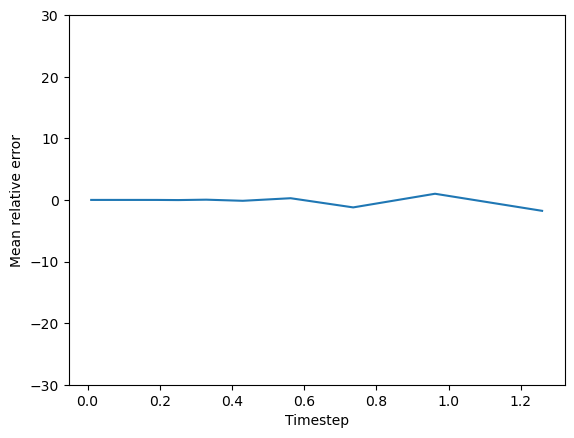

In [ ]:
mape = np.array(1000.0 * (c_range - P12)/P12)

plt.figure()
plt.plot(dt_list, mape)
plt.xlabel('Timestep')
plt.ylabel('Mean relative error')
plt.ylim([-30, 30])
plt.show()